# Heart Disease Dataset — Evaluation

**Objective:** Deep evaluation of the best model (Logistic Regression) and honest reflection on the project.  

This notebook covers:
- Detailed performance analysis of Logistic Regression
- Threshold analysis — what happens if we lower the decision boundary
- Logistic Regression coefficients — which features drive predictions
- Limitations of the project
- Suggested improvements for future work

## 1. Import Libraries & Load Data

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import os

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    precision_recall_curve, roc_curve, classification_report
)

os.makedirs('../plots', exist_ok=True)
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (10, 5)

print('Libraries loaded.')

Libraries loaded.


In [5]:
# Load preprocessed splits saved in notebook 2
X_train = pd.read_csv('../data/processed/X_train.csv')
X_test  = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test  = pd.read_csv('../data/processed/y_test.csv').squeeze()

# Retrain best model — Logistic Regression
best_model = LogisticRegression(max_iter=1000, random_state=42)
best_model.fit(X_train, y_train)

# Generate predictions and probabilities on the test set
y_pred      = best_model.predict(X_test)
y_pred_prob = best_model.predict_proba(X_test)[:, 1]  # probability of heart disease

print('Model trained and predictions generated.')

Model trained and predictions generated.


## 2. Full Classification Report

In [6]:
# Detailed per-class breakdown of precision, recall, and F1
print('=== Logistic Regression — Classification Report ===')
print(classification_report(y_test, y_pred,
                             target_names=['No Disease (0)', 'Heart Disease (1)']))

# Summary metrics
print(f'Accuracy:  {accuracy_score(y_test, y_pred):.3f}')
print(f'Precision: {precision_score(y_test, y_pred):.3f}')
print(f'Recall:    {recall_score(y_test, y_pred):.3f}')
print(f'F1:        {f1_score(y_test, y_pred):.3f}')
print(f'AUC-ROC:   {roc_auc_score(y_test, y_pred_prob):.3f}')

=== Logistic Regression — Classification Report ===
                   precision    recall  f1-score   support

   No Disease (0)       0.81      0.78      0.79        27
Heart Disease (1)       0.82      0.85      0.84        33

         accuracy                           0.82        60
        macro avg       0.82      0.81      0.81        60
     weighted avg       0.82      0.82      0.82        60

Accuracy:  0.817
Precision: 0.824
Recall:    0.848
F1:        0.836
AUC-ROC:   0.866


## 3. Confusion Matrix — Detailed

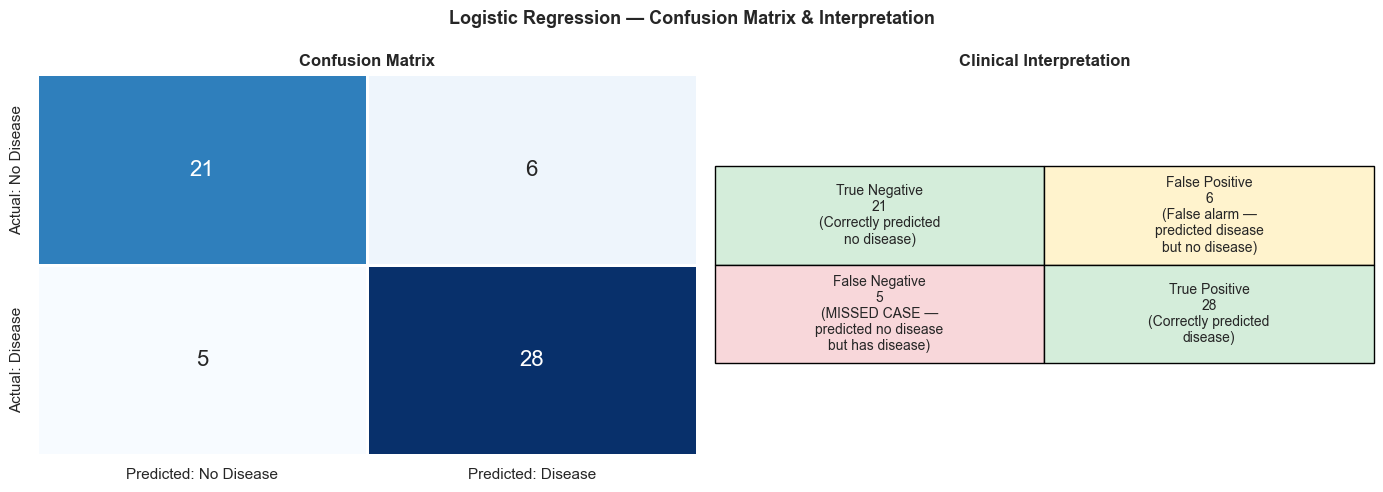

True Positives  (correctly caught disease):    28
True Negatives  (correctly cleared no disease): 21
False Positives (false alarms):                6
False Negatives (missed disease cases):        5  ← most critical


In [8]:
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Heatmap ---
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Predicted: No Disease', 'Predicted: Disease'],
            yticklabels=['Actual: No Disease', 'Actual: Disease'],
            linewidths=1, cbar=False, annot_kws={'size': 16})
axes[0].set_title('Confusion Matrix', fontweight='bold')

# --- Labelled breakdown ---
# Visually explains what each cell in the matrix means clinically
labels = [
    [f'True Negative\n{tn}\n(Correctly predicted\nno disease)',
     f'False Positive\n{fp}\n(False alarm —\npredicted disease\nbut no disease)'],
    [f'False Negative\n{fn}\n(MISSED CASE —\npredicted no disease\nbut has disease)',
     f'True Positive\n{tp}\n(Correctly predicted\ndisease)']
]
colors = [['#d4edda', '#fff3cd'], ['#f8d7da', '#d4edda']]

axes[1].axis('off')
table = axes[1].table(
    cellText=labels,
    cellColours=colors,
    cellLoc='center',
    loc='center'
)
table.scale(1, 6)
table.auto_set_font_size(False)
table.set_fontsize(10)
axes[1].set_title('Clinical Interpretation', fontweight='bold')

plt.suptitle('Logistic Regression — Confusion Matrix & Interpretation',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../plots/eval_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'True Positives  (correctly caught disease):    {tp}')
print(f'True Negatives  (correctly cleared no disease): {tn}')
print(f'False Positives (false alarms):                {fp}')
print(f'False Negatives (missed disease cases):        {fn}  ← most critical')

## 4. ROC Curve — Detailed

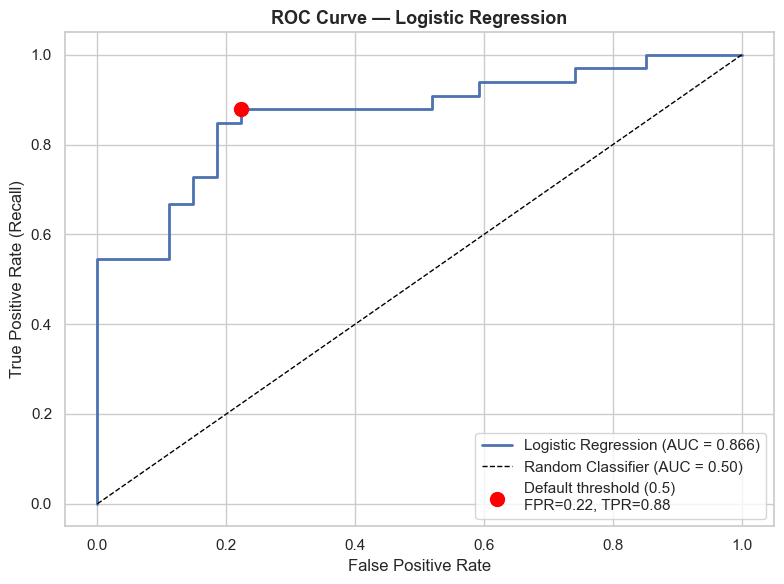

In [9]:
# ROC curve for Logistic Regression with the default threshold (0.5) marked
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
auc = roc_auc_score(y_test, y_pred_prob)

# Find the point on the curve closest to the default 0.5 threshold
default_idx = np.argmin(np.abs(thresholds - 0.5))

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#4C72B0', linewidth=2, label=f'Logistic Regression (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier (AUC = 0.50)')

# Mark the default threshold operating point
plt.scatter(fpr[default_idx], tpr[default_idx], color='red', zorder=5, s=100,
            label=f'Default threshold (0.5)\nFPR={fpr[default_idx]:.2f}, TPR={tpr[default_idx]:.2f}')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve — Logistic Regression', fontsize=13, fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('../plots/eval_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Precision-Recall Curve

The Precision-Recall curve is especially useful in medical contexts.  
It shows the trade-off between catching all disease cases (high recall)  
and avoiding false alarms (high precision).

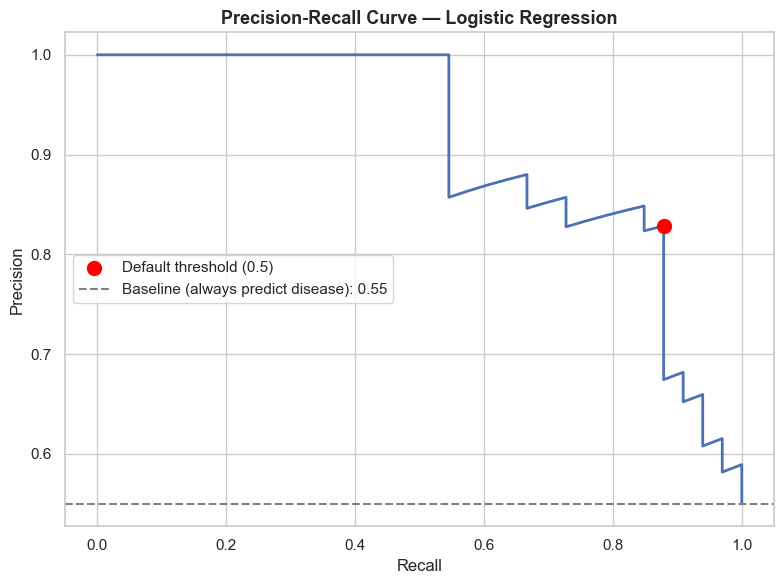

In [11]:
precision_vals, recall_vals, pr_thresholds = precision_recall_curve(y_test, y_pred_prob)

plt.figure(figsize=(8, 6))
plt.plot(recall_vals, precision_vals, color='#4C72B0', linewidth=2)

# Mark the default 0.5 threshold operating point
default_pr_idx = np.argmin(np.abs(pr_thresholds - 0.5))
plt.scatter(recall_vals[default_pr_idx], precision_vals[default_pr_idx],
            color='red', zorder=5, s=100, label='Default threshold (0.5)')

# Baseline: a classifier that always predicts the majority class
baseline = y_test.mean()
plt.axhline(y=baseline, color='gray', linestyle='--',
            label=f'Baseline (always predict disease): {baseline:.2f}')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve — Logistic Regression', fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('../plots/eval_precision_recall.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Threshold Analysis

By default, classifiers use a threshold of 0.5 — if the predicted probability  
of disease exceeds 0.5, the patient is classified as having heart disease.  

In a medical context we may want to **lower the threshold** (e.g. to 0.3 or 0.4)  
to catch more disease cases at the cost of more false alarms.  
This section explores how metrics change across different thresholds.

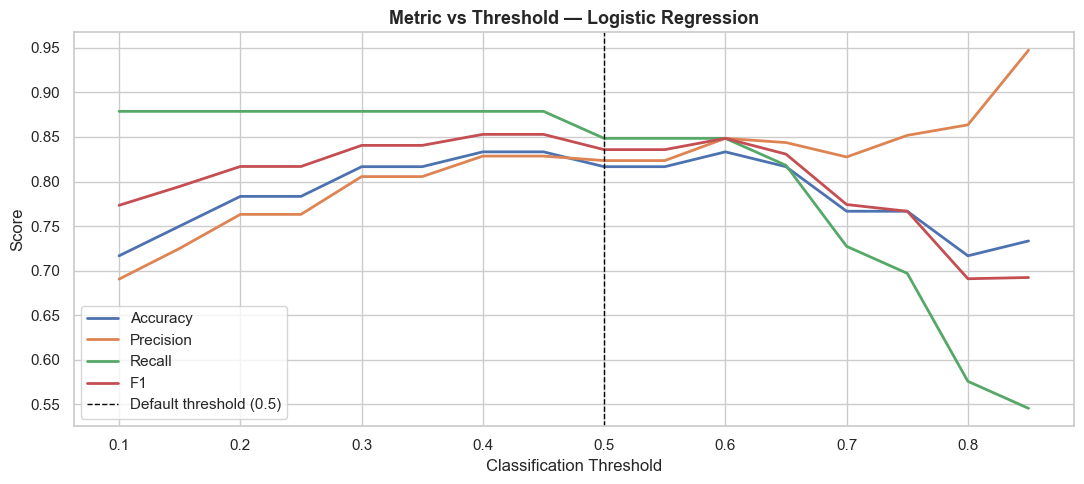

 Threshold  Accuracy  Precision  Recall    F1
      0.10     0.717      0.690   0.879 0.773
      0.15     0.750      0.725   0.879 0.795
      0.20     0.783      0.763   0.879 0.817
      0.25     0.783      0.763   0.879 0.817
      0.30     0.817      0.806   0.879 0.841
      0.35     0.817      0.806   0.879 0.841
      0.40     0.833      0.829   0.879 0.853
      0.45     0.833      0.829   0.879 0.853
      0.50     0.817      0.824   0.848 0.836
      0.55     0.817      0.824   0.848 0.836
      0.60     0.833      0.848   0.848 0.848
      0.65     0.817      0.844   0.818 0.831
      0.70     0.767      0.828   0.727 0.774
      0.75     0.767      0.852   0.697 0.767
      0.80     0.717      0.864   0.576 0.691
      0.85     0.733      0.947   0.545 0.692


In [12]:
# Compute Accuracy, Precision, Recall, and F1 at each threshold value
thresholds_range = np.arange(0.1, 0.9, 0.05)
threshold_results = []

for t in thresholds_range:
    y_pred_t = (y_pred_prob >= t).astype(int)  # apply threshold to probabilities
    threshold_results.append({
        'Threshold': t,
        'Accuracy':  accuracy_score(y_test, y_pred_t),
        'Precision': precision_score(y_test, y_pred_t, zero_division=0),
        'Recall':    recall_score(y_test, y_pred_t, zero_division=0),
        'F1':        f1_score(y_test, y_pred_t, zero_division=0)
    })

thresh_df = pd.DataFrame(threshold_results)

# Plot how each metric changes as the threshold moves
plt.figure(figsize=(11, 5))
for metric, color in zip(['Accuracy', 'Precision', 'Recall', 'F1'],
                          ['#4C72B0', '#DD8452', '#55A868', '#C44E52']):
    plt.plot(thresh_df['Threshold'], thresh_df[metric],
             label=metric, color=color, linewidth=2)

# Mark the default 0.5 threshold
plt.axvline(0.5, color='black', linestyle='--', linewidth=1, label='Default threshold (0.5)')
plt.xlabel('Classification Threshold')
plt.ylabel('Score')
plt.title('Metric vs Threshold — Logistic Regression', fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('../plots/eval_threshold_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(thresh_df.round(3).to_string(index=False))

## 7. Logistic Regression Coefficients

Unlike tree-based models, Logistic Regression is fully interpretable.  
Each coefficient represents the log-odds change in the probability of heart disease  
for a one-unit increase in that feature (after scaling).  
Positive coefficient → feature increases disease probability.  
Negative coefficient → feature decreases disease probability.

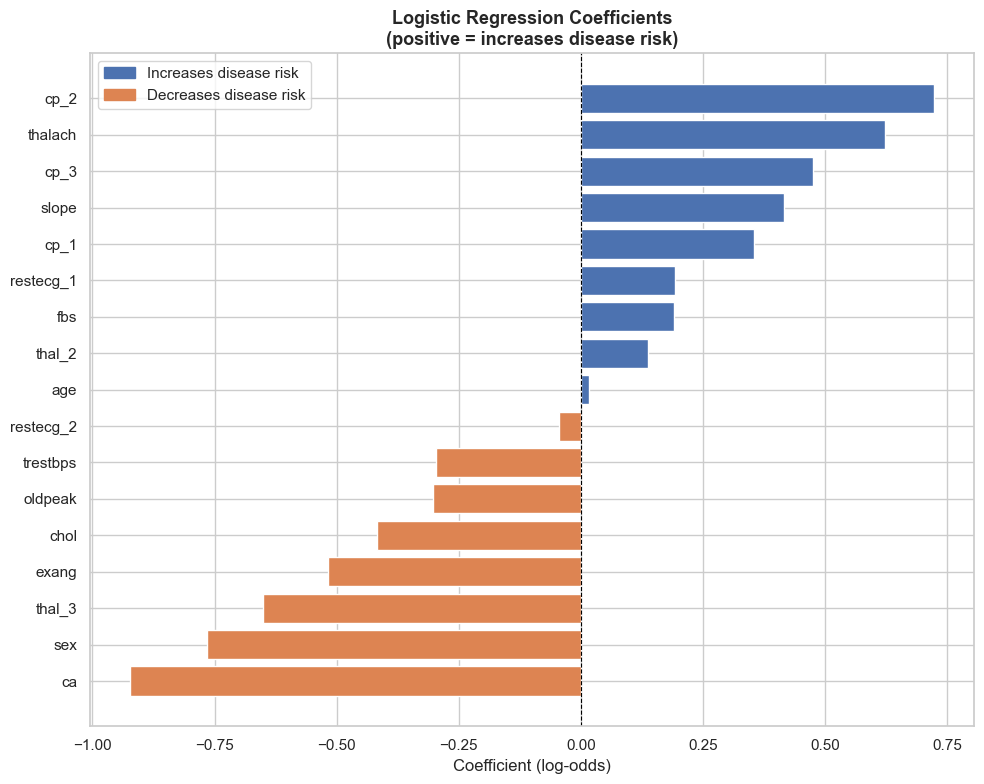

Top 5 features INCREASING disease risk:
Feature  Coefficient
   cp_1        0.353
  slope        0.416
   cp_3        0.475
thalach        0.621
   cp_2        0.722

Top 5 features DECREASING disease risk:
Feature  Coefficient
     ca       -0.922
    sex       -0.765
 thal_3       -0.651
  exang       -0.517
   chol       -0.417


In [14]:
# Extract and sort coefficients by magnitude
coef_df = pd.DataFrame({
    'Feature':     X_train.columns,
    'Coefficient': best_model.coef_[0]
}).sort_values('Coefficient')

# Colour by direction: positive = blue (increases disease risk), negative = orange
colors = ['#DD8452' if c < 0 else '#4C72B0' for c in coef_df['Coefficient']]

plt.figure(figsize=(10, 8))
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.xlabel('Coefficient (log-odds)')
plt.title('Logistic Regression Coefficients\n(positive = increases disease risk)',
          fontsize=13, fontweight='bold')

# Legend
pos_patch = mpatches.Patch(color='#4C72B0', label='Increases disease risk')
neg_patch = mpatches.Patch(color='#DD8452', label='Decreases disease risk')
plt.legend(handles=[pos_patch, neg_patch])

plt.tight_layout()
plt.savefig('../plots/eval_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 5 features INCREASING disease risk:')
print(coef_df.tail(5)[['Feature', 'Coefficient']].round(3).to_string(index=False))
print('\nTop 5 features DECREASING disease risk:')
print(coef_df.head(5)[['Feature', 'Coefficient']].round(3).to_string(index=False))

## 8. Prediction Probability Distribution

Visualising the model's predicted probabilities for both classes.  
A well-calibrated model should show clear separation between the two distributions —  
disease patients should cluster near 1.0 and healthy patients near 0.0.

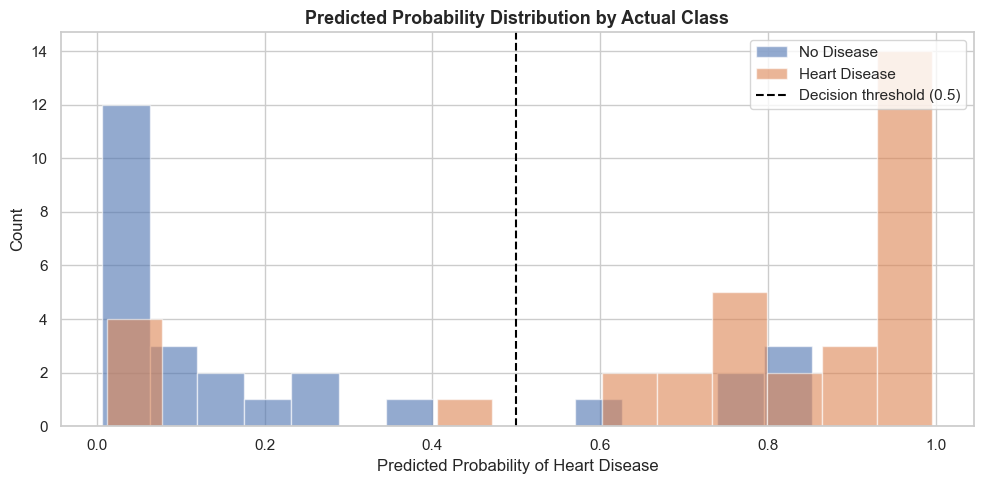

In [15]:
plt.figure(figsize=(10, 5))

# Plot predicted probability distribution for each actual class
for target_val, label, color in zip([0, 1], ['No Disease', 'Heart Disease'],
                                     ['#4C72B0', '#DD8452']):
    probs = y_pred_prob[y_test == target_val]
    plt.hist(probs, bins=15, alpha=0.6, label=label, color=color, edgecolor='white')

# Mark the default decision threshold
plt.axvline(0.5, color='black', linestyle='--', linewidth=1.5, label='Decision threshold (0.5)')
plt.xlabel('Predicted Probability of Heart Disease')
plt.ylabel('Count')
plt.title('Predicted Probability Distribution by Actual Class',
          fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('../plots/eval_probability_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Limitations & Improvements

### Limitations

**1. Small dataset after deduplication**  
After removing 723 duplicate rows the dataset was reduced to ~300 samples.
This limits the model's ability to generalise to unseen patients and means
performance estimates carry high uncertainty (wide CV standard deviations).

**2. No hyperparameter tuning**  
All models were trained with default or lightly adjusted hyperparameters.
Techniques such as GridSearchCV or RandomizedSearchCV were not applied,
meaning the models may not be operating at their optimal configuration.
This was a deliberate choice given the small dataset size — extensive tuning
on ~240 training samples risks overfitting to the tuning process itself.

**3. No advanced ensemble methods**  
Techniques such as model stacking, voting classifiers, or custom bagging
were not explored. These approaches can improve performance by combining
the strengths of multiple models but require larger datasets to be reliable.

**4. Gender bias in the data**  
The dataset contains 206 male patients and only 96 female patients. The model
is trained predominantly on male patient data and may perform less reliably
when predicting heart disease risk in female patients.

**5. Fixed decision threshold**  
The default classification threshold of 0.5 was used throughout. As shown
in the threshold analysis (Section 6), adjusting this value changes the
Recall/Precision trade-off. In a real clinical setting, a lower threshold
would likely be preferred to minimise missed disease cases.

**6. Dataset origin and generalisability**  
The dataset combines data from four different hospital databases (Cleveland,
Hungary, Switzerland, VA Long Beach). Differences in measurement protocols
between sites may introduce inconsistencies. The model has not been validated
on an independent external dataset.

---

### Improvements for Future Work

**1. Acquire more data**  
The single most impactful improvement would be training on a larger, cleaner
dataset. More data would reduce CV variance, enable reliable hyperparameter
tuning, and improve generalisation.

**2. Hyperparameter tuning**  
Apply RandomizedSearchCV with cross-validation to tune key parameters such
as regularisation strength (C) for Logistic Regression and SVM, number of
estimators and max depth for Random Forest and XGBoost.

**3. Model stacking**  
Train a meta-model (e.g. Logistic Regression) on the predictions of the four
base models. Stacking often outperforms any individual model by combining
complementary strengths.

**4. Threshold optimisation**  
Select the classification threshold based on the clinical cost of False
Negatives vs False Positives rather than defaulting to 0.5. In heart disease
prediction, a threshold of ~0.3–0.4 may be more appropriate.

**5. SHAP values for explainability**  
Apply SHAP (SHapley Additive exPlanations) to explain individual predictions.
This is particularly important in medical applications where clinicians need
to understand *why* a model flagged a specific patient.

**6. External validation**  
Evaluate the final model on a completely separate dataset from a different
hospital or population to test true generalisability.

## 10. Final Project Summary

| Component | Detail |
|---|---|
| **Problem** | Binary classification — predict presence of heart disease |
| **Dataset** | 302 patients (post-deduplication), 14 features |
| **Best Model** | Logistic Regression |
| **Accuracy** | 0.82 |
| **Recall** | 0.85 (5 missed disease cases out of 33) |
| **AUC-ROC** | 0.87 |
| **Top Predictors** | cp, thalach, exang, ca, thal |
| **Key Limitation** | Small dataset after deduplication limits generalisation |
| **Key Improvement** | Hyperparameter tuning and model stacking on larger dataset |